# 504: Peak Warming vs Net-Zero CO2 Year

This notebook analyzes the relationship between peak warming (GSAT|ANTHROPOGENIC|peak) and the year of net-zero CO2 emissions.

In [282]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from scipy import stats as scipy_stats
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D

dotenv.load_dotenv()

OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

# Load IPCC color palette
with open("ipcc_colors.yml") as f:
    IPCC_COLORS = yaml.safe_load(f)

In [ ]:
# Load cumulative net-negative CO2 and CH4 decline groups from 201

meta_105 = pd.read_csv(OUTPUT_FOLDER / "201_netzero_timings_cumnetnegco2.csv")
meta_105["scenario_group"]="Scenarios (NZCO2)"
meta_105_svnzco2 = pd.read_csv(OUTPUT_FOLDER / "201_netzero_timings_cumnetnegco2-svnzco2.csv")
meta_105_svnzghg = pd.read_csv(OUTPUT_FOLDER / "201_netzero_timings_cumnetnegco2-svnzghg.csv")

In [208]:
# Input metrics file
MANIFEST_ID = "regenerated"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv"

metrics_df = pd.read_csv(METRICS_FILE, index_col=0)
metrics_df["scenario"] = metrics_df["scenario"].str.replace("_NZCO2", "", regex=False).str.replace("_NZKyoto", "", regex=False)

print(f"Loaded {len(metrics_df):,} runs")

Loaded 1,215,600 runs


In [209]:
# Get model/scenario combinations from Scenarios (NZGHG) group
nzghg_combos = (
    metrics_df[metrics_df["scenario_group"] == "Scenarios (NZGHG)"]
    [["model", "scenario"]]
    .drop_duplicates()
)

# Filter meta_105 to only those combinations
meta_105_nzghg = meta_105.merge(
    nzghg_combos,
    on=["model", "scenario"],
    how="inner"
)

meta_105_nzghg["scenario_group"] = "Scenarios (NZGHG)"
print(f"Scenarios in Scenarios (NZGHG): {len(nzghg_combos)}")
print(f"Matched in meta_105: {len(meta_105_nzghg)}")

Scenarios in Scenarios (NZGHG): 328
Matched in meta_105: 328


In [210]:
meta_105_new = pd.concat([meta_105, meta_105_nzghg, meta_105_svnzco2, meta_105_svnzghg])

meta_105_new = meta_105_new[["model", "scenario", "scenario_group", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"]].copy()

In [211]:
# Merge with metrics_df
metrics_df = metrics_df.merge(meta_105_new, on=["model", "scenario", "scenario_group"], how="left")
#print(f"Merged metadata for {metrics_df['cumulative_netnegative_co2'].notna().sum():,} runs")

metrics_df.head()

,model,scenario,run_id,peak_year,year_netzero_co2,GSAT|ALL|peak,GSAT|ALL|netzero_co2,GSAT|ALL|2100,GSAT|NonCO2_GHG|peak_gsat,GSAT|NonCO2_GHG|2100,...,GSAT|CO2_Negative|delta_peak_gsat,GSAT|CO2_Negative|netzero_co2,GSAT|CO2_Negative|delta_netzero_co2,scenario_group,GSAT|ALL|delta_netzero_co2,GSAT|ALL|delta_peak_gsat,is_decline,cumulative_netnegative_co2,ch4_decline,ch4_decline_group
0,AIM/CGE 2.0,SSP1-19,0,2049,2058,1.612907,1.578769,1.411091,0.092336,-0.093244,...,-0.065621,0.0,-0.065621,Scenarios (NZCO2),-0.167678,-0.201816,True,-135.79,261.96,High CH4 decline
1,AIM/CGE 2.0,SSP1-19,1,2093,2058,2.592601,2.542383,2.577173,0.438947,0.419883,...,-0.024810,0.0,-0.096158,Scenarios (NZCO2),0.034790,-0.015427,False,-135.79,261.96,High CH4 decline
2,AIM/CGE 2.0,SSP1-19,2,2049,2058,1.798363,1.756857,1.577004,0.099817,-0.076595,...,-0.069052,0.0,-0.069052,Scenarios (NZCO2),-0.179853,-0.221359,True,-135.79,261.96,High CH4 decline
3,AIM/CGE 2.0,SSP1-19,3,2038,2058,1.379944,1.300197,1.074082,0.098739,-0.197705,...,-0.052731,0.0,-0.052731,Scenarios (NZCO2),-0.226115,-0.305862,True,-135.79,261.96,High CH4 decline
4,AIM/CGE 2.0,SSP1-19,4,2048,2058,1.645092,1.590230,1.396311,0.107123,-0.111821,...,-0.062936,0.0,-0.062936,Scenarios (NZCO2),-0.193919,-0.248781,True,-135.79,261.96,High CH4 decline


In [212]:
# Calculate median and percentiles of GSAT|ANTHROPOGENIC|peak per scenario
scenario_stats = metrics_df.groupby(["model", "scenario", "scenario_group"]).agg({
    "GSAT|ANTHROPOGENIC|peak": [
        lambda x: x.quantile(0.05),
        lambda x: x.quantile(0.33),
        "median",
        lambda x: x.quantile(0.67),
        lambda x: x.quantile(0.95)
    ],
 #   "GSAT|ANTHROPOGENIC|delta_netzero_co2": "median",
 #   "GSAT|CO2_NZCO2|delta_netzero_co2": "median",
    "year_netzero_co2": "first",
    "cumulative_netnegative_co2": "first",
    "ch4_decline": "first",
    "ch4_decline_group": "first"
}).reset_index()

# Flatten column names
scenario_stats.columns = ["model", "scenario", "scenario_group", "peak_p05", "peak_p33", "peak_median", "peak_p67", "peak_p95",
                       #   "delta_all_median", "delta_co2_nzco2_median", 
                          "year_netzero_co2", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"]

print(f"Scenarios: {len(scenario_stats)}")
print(f"\nCH4 decline group value counts:")
print(scenario_stats["ch4_decline_group"].value_counts(dropna=False))
print(f"\nUnique values: {scenario_stats['ch4_decline_group'].unique()}")

Scenarios: 2026

CH4 decline group value counts:
ch4_decline_group
High CH4 decline      722
Medium CH4 decline    676
Low CH4 decline       628
Name: count, dtype: int64

Unique values: ['High CH4 decline' 'Low CH4 decline' 'Medium CH4 decline']


In [213]:
scenario_stats

,model,scenario,scenario_group,peak_p05,peak_p33,peak_median,peak_p67,peak_p95,year_netzero_co2,cumulative_netnegative_co2,ch4_decline,ch4_decline_group
0,AIM/CGE 2.0,SSP1-19,Scenarios (NZCO2),1.185548,1.439749,1.543185,1.668978,2.102762,2058,-135.79,261.96,High CH4 decline
1,AIM/CGE 2.0,SSP1-19,Scenarios (NZGHG),1.185548,1.439749,1.543185,1.668978,2.102762,2058,-135.79,261.96,High CH4 decline
2,AIM/CGE 2.0,SSP1-19,Stylised Variants (NZCO2-hold),1.185548,1.439749,1.543185,1.668978,2.118689,2058,-10.41,261.96,High CH4 decline
3,AIM/CGE 2.0,SSP1-19,Stylised Variants (NZGHG-hold),1.185548,1.439749,1.543185,1.668978,2.102762,2058,-121.11,261.96,High CH4 decline
4,AIM/CGE 2.0,SSP2-19,Scenarios (NZCO2),1.173956,1.414497,1.513349,1.630569,2.001557,2051,-351.99,238.26,High CH4 decline
...,...,...,...,...,...,...,...,...,...,...,...,...
2021,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,Stylised Variants (NZGHG-hold),1.184251,1.461290,1.590866,1.718674,2.295137,2079,-79.83,191.53,High CH4 decline
2022,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,Scenarios (NZCO2),1.126743,1.365045,1.458591,1.560345,1.952821,2059,-352.51,199.12,High CH4 decline
2023,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,Scenarios (NZGHG),1.126743,1.365045,1.458591,1.560345,1.952821,2059,-352.51,199.12,High CH4 decline
2024,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,Stylised Variants (NZCO2-hold),1.126743,1.365045,1.458591,1.560345,1.971695,2059,-16.72,199.12,High CH4 decline


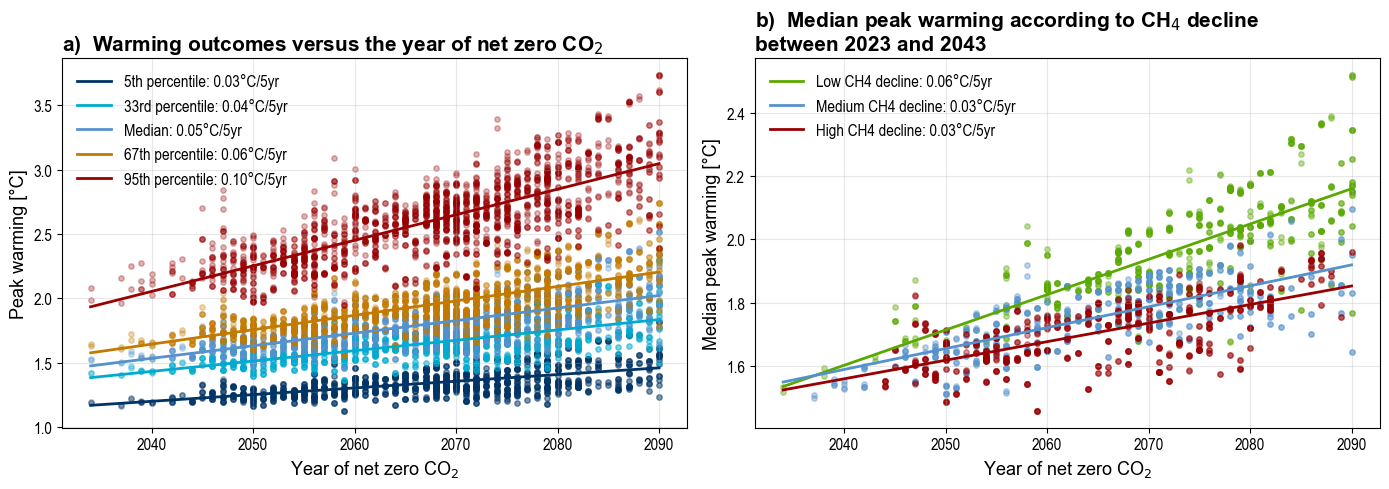

In [214]:
# Scatter plot: Peak warming vs net-zero CO2 year
# Panel 1: All percentiles (no CH4 grouping)
# Panel 2: Median only, grouped by CH4 decline

# Set up fonts
#plt.rcParams['font.family'] = 'Arial'
#plt.rcParams['font.sans-serif'] = ['Arial']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Filter for valid data
plot_data = scenario_stats.dropna(subset=["ch4_decline_group", "year_netzero_co2"]).copy()

x_all = plot_data["year_netzero_co2"].values
x_fit = np.linspace(plot_data["year_netzero_co2"].min(), plot_data["year_netzero_co2"].max(), 100)

# --- Panel 1: All percentiles, no CH4 grouping ---
ax1 = axes[0]

percentile_colors = {
    "peak_p05": "#003466",    # Dark Blue
    "peak_p33": "#00aad0",    # Warm Blue
    "peak_median": "#5492cd", # IPCC Blue
    "peak_p67": "#c47900",    # Warm Mustard
    "peak_p95": "#990002",    # Warm Red
}
percentile_labels = {
    "peak_p05": "5th percentile",
    "peak_p33": "33rd percentile",
    "peak_median": "Median",
    "peak_p67": "67th percentile",
    "peak_p95": "95th percentile",
}

for col in ["peak_p05", "peak_p33", "peak_median", "peak_p67", "peak_p95"]:
    y = plot_data[col].values
    hex_color = percentile_colors[col]
    label = percentile_labels[col]
    
    ax1.scatter(x_all, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.3, s=15)
    
    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x_all[valid], y[valid], 1)
        ax1.plot(x_fit, slope * x_fit + intercept, 
                color=hex_color, linewidth=2,
                label=f"{label}: {slope*5:.2f}°C/5yr")

ax1.set_xlabel("Year of net zero CO$_2$", fontname="Arial", fontsize=13)
ax1.set_ylabel("Peak warming [°C]", fontname="Arial", fontsize=13)
ax1.set_title("a)  Warming outcomes versus the year of net zero CO$_2$", loc="left", 
              fontname="Arial", fontsize=15, fontweight="bold")
ax1.legend(fontsize=12, loc="upper left", frameon=False, prop={"family": "Arial Narrow", "size": 12})
ax1.grid(alpha=0.3)
ax1.tick_params(axis='both', labelsize=12)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontname("Arial Narrow")

# --- Panel 2: Median only, grouped by CH4 decline ---
ax2 = axes[1]

GROUP_COLORS = {
    "Low CH4 decline": "#59a900",      # Bright Green
    "Medium CH4 decline": "#5492cd",   # IPCC Blue
    "High CH4 decline": "#990002",     # Warm Red
}

for group in ["Low CH4 decline", "Medium CH4 decline", "High CH4 decline"]:
    subset = plot_data[plot_data["ch4_decline_group"] == group]
    x = subset["year_netzero_co2"].values
    y = subset["peak_median"].values
    hex_color = GROUP_COLORS[group]
    
    ax2.scatter(x, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.4, s=15)
    
    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x[valid], y[valid], 1)
        ax2.plot(x_fit, slope * x_fit + intercept, 
                color=hex_color, linewidth=2,
                label=f"{group}: {slope*5:.2f}°C/5yr")

ax2.set_xlabel("Year of net zero CO$_2$", fontname="Arial", fontsize=13)
ax2.set_ylabel("Median peak warming [°C]", fontname="Arial", fontsize=13)
ax2.set_title("b)  Median peak warming according to CH$_4$ decline\nbetween 2023 and 2043", loc="left",
              fontname="Arial", fontsize=15, fontweight="bold")
ax2.legend(fontsize=12, loc="upper left", frameon=False, prop={"family": "Arial Narrow", "size": 12})
ax2.grid(alpha=0.3)
ax2.tick_params(axis='both', labelsize=12)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontname("Arial Narrow")

plt.tight_layout()

# Save figure in high resolution PNG and SVG formats
fig.savefig(PLOT_FOLDER / "504_peak_warming_vs_netzero.png", dpi=300, bbox_inches='tight')
fig.savefig(PLOT_FOLDER / "504_peak_warming_vs_netzero.svg", bbox_inches='tight')
print(f"Saved to {OUTPUT_FOLDER / '504_peak_warming_vs_netzero.png'}")
print(f"Saved to {OUTPUT_FOLDER / '504_peak_warming_vs_netzero.svg'}")

## NZCO2 year

In [232]:
# Calculate median and percentiles of GSAT|ANTHROPOGENIC|peak per scenario
scenario_stats = metrics_df.groupby(["model", "scenario", "scenario_group"]).agg({
    "GSAT|ANTHROPOGENIC|2100": [
        lambda x: x.quantile(0.05),
        lambda x: x.quantile(0.18),
        lambda x: x.quantile(0.33),
        "median",
        lambda x: x.quantile(0.67),
        lambda x: x.quantile(0.83),
        lambda x: x.quantile(0.95)
    ],
    "year_netzero_co2": "first",
    "cumulative_netnegative_co2": "first",
    "ch4_decline": "first",
    "ch4_decline_group": "first"
}).reset_index()

# Flatten column names
scenario_stats.columns = ["model", "scenario", "scenario_group", "peak_p05", "peak_p17", "peak_p33", "peak_median", "peak_p67", "peak_p83", "peak_p95",
                          "year_netzero_co2", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"
                         ]  
print(f"Scenarios: {len(scenario_stats)}")

Scenarios: 2026


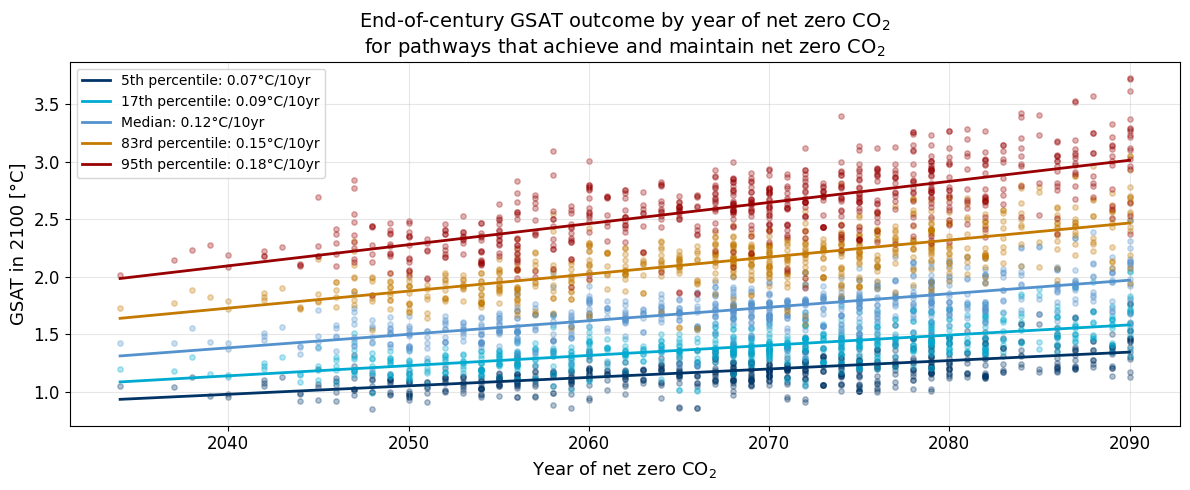

In [225]:
fig, ax = plt.subplots(figsize=(12, 5))

# Filter for valid data
plot_data = scenario_stats.dropna(subset=["year_netzero_co2"]).copy()
plot_data = plot_data[plot_data["scenario_group"]=="Stylised Variants (NZCO2-hold)"]

x_all = plot_data["year_netzero_co2"].values
x_fit = np.linspace(plot_data["year_netzero_co2"].min(), plot_data["year_netzero_co2"].max(), 100)

percentile_colors = {
    "peak_p05":     "#003466",
    "peak_p17":     "#00aad0",
#    "peak_p33":     "#00aad0",
    "peak_median":  "#5492cd",
#    "peak_p67":     "#c47900",
    "peak_p83":     "#c47900",
    "peak_p95":     "#990002",
}
percentile_labels = {
    "peak_p05":     "5th percentile",
    "peak_p17":     "17th percentile",
#    "peak_p33":     "33rd percentile",
    "peak_median":  "Median",
#    "peak_p67":     "67th percentile",
    "peak_p83":     "83rd percentile",
    "peak_p95":     "95th percentile",
}

for col in ["peak_p05", "peak_p17", "peak_median", "peak_p83", "peak_p95"]:
    y = plot_data[col].values
    hex_color = percentile_colors[col]
    label = percentile_labels[col]

    ax.scatter(x_all, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.3, s=15)

    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x_all[valid], y[valid], 1)
        ax.plot(x_fit, slope * x_fit + intercept,
                color=hex_color, linewidth=2,
                label=f"{label}: {slope*10:.2f}°C/10yr")

ax.set_xlabel("Year of net zero CO$_2$", fontsize=13)
#ax.set_ylabel("GSAT in year of net zero CO$_2$ [°C]", fontsize=13)
ax.set_ylabel("GSAT in 2100 [°C]", fontsize=13)
ax.set_title("End-of-century GSAT outcome by year of net zero CO$_2$\nfor pathways that achieve and maintain net zero CO$_2$", fontsize=14)
ax.legend(fontsize=10, loc="upper left")
ax.grid(alpha=0.3)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "GSAT_2100_vs_nzco2-10.png", dpi=300, bbox_inches="tight")
plt.show()

## per scenario group

scenario_group
Scenarios (NZCO2)                 685
Stylised Variants (NZCO2-hold)    685
Scenarios (NZGHG)                 328
Stylised Variants (NZGHG-hold)    328
Name: count, dtype: int64
Scenarios (NZCO2): 685 scenarios
Scenarios (NZGHG): 328 scenarios
Stylised Variants (NZCO2-hold): 685 scenarios
Stylised Variants (NZGHG-hold): 328 scenarios


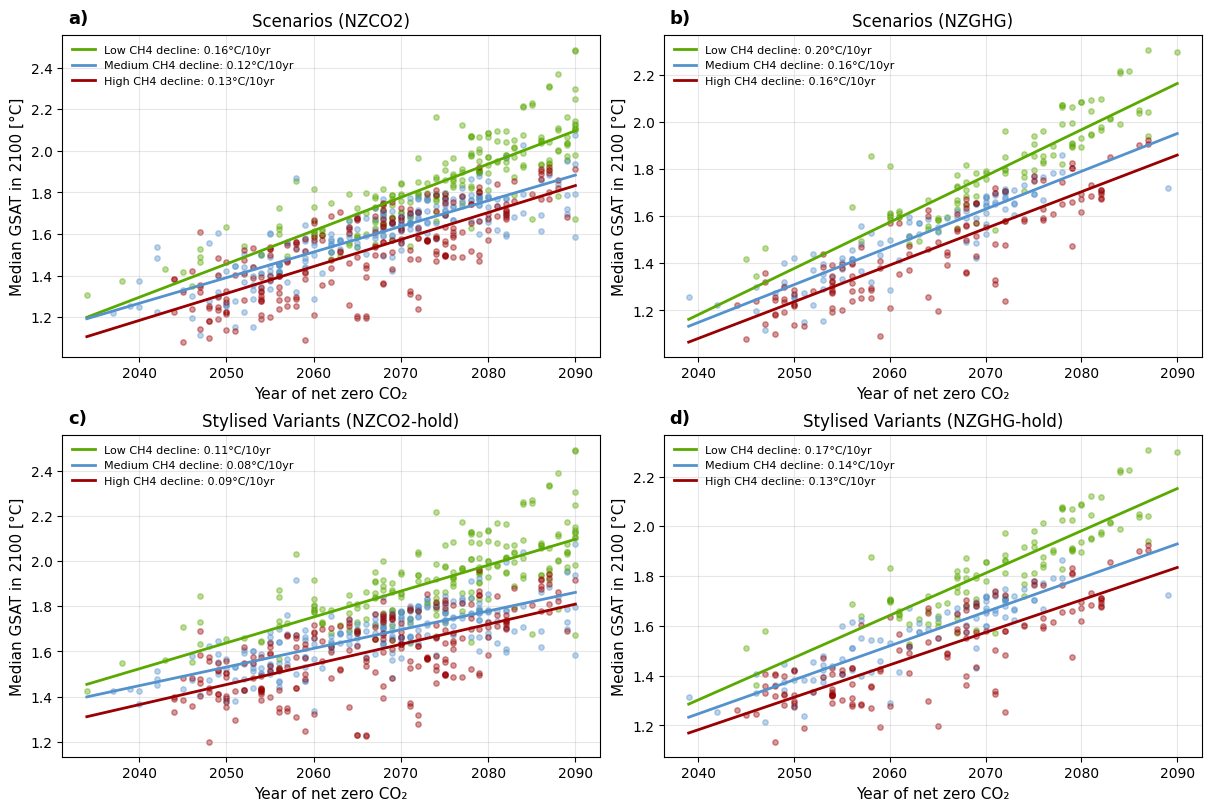

In [238]:
plot_data = scenario_stats.dropna(subset=["year_netzero_co2"]).copy()

# Check what scenario_groups are actually present
print(plot_data["scenario_group"].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

GROUP_COLORS = {
    "Low CH4 decline":    "#59a900",
    "Medium CH4 decline": "#5492cd",
    "High CH4 decline":   "#990002",
}
groups = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]

for ax, scenario_group in zip(axes.flatten(), groups):
    plot_data_sel = plot_data[plot_data["scenario_group"] == scenario_group]
    print(f"{scenario_group}: {len(plot_data_sel)} scenarios")  # debug

    if plot_data_sel.empty:
        ax.set_title(f"{scenario_group} (no data)", fontsize=12)
        continue

    x_fit = np.linspace(plot_data_sel["year_netzero_co2"].min(), plot_data_sel["year_netzero_co2"].max(), 100)

    for group in ["Low CH4 decline", "Medium CH4 decline", "High CH4 decline"]:
        subset = plot_data_sel[plot_data_sel["ch4_decline_group"] == group]
        x = subset["year_netzero_co2"].values
        y = subset["peak_median"].values
        hex_color = GROUP_COLORS[group]

        ax.scatter(x, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.4, s=15)

        valid = ~np.isnan(y)
        if valid.sum() > 1:
            slope, intercept = np.polyfit(x[valid], y[valid], 1)
            ax.plot(x_fit, slope * x_fit + intercept,
                    color=hex_color, linewidth=2,
                    label=f"{group}: {slope*10:.2f}°C/10yr")

    ax.set_xlabel("Year of net zero CO₂", fontsize=11)
    ax.set_ylabel("Median GSAT in 2100 [°C]", fontsize=11)
    ax.set_title(scenario_group, fontsize=12)
    ax.legend(fontsize=8, loc="upper left", frameon=False)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="both", labelsize=10)

for ax, label in zip(axes.flatten(), ["a)", "b)", "c)", "d)"]):
    ax.annotate(label, xy=(0.01, 1.08), xycoords="axes fraction",
                fontsize=13, fontweight="bold", va="top", ha="left")

plt.savefig(PLOT_FOLDER / "GSAT_2100_CH4_vs_nzco2_4panel.png", dpi=300, bbox_inches="tight")
plt.show()

Scenarios (NZCO2): 685 scenarios
Scenarios (NZGHG): 328 scenarios
Stylised Variants (NZCO2-hold): 685 scenarios
Stylised Variants (NZGHG-hold): 328 scenarios


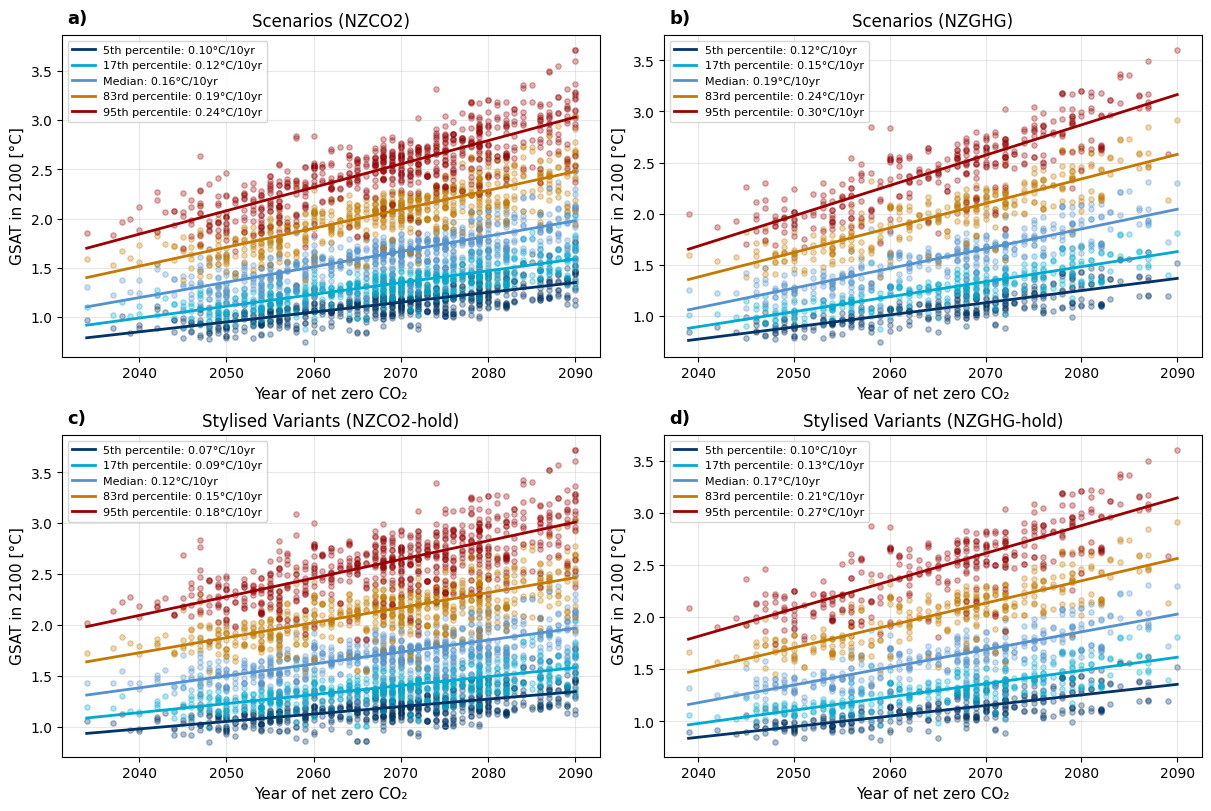

In [236]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

percentile_colors = {
    "peak_p05":    "#003466",
    "peak_p17":    "#00aad0",
    "peak_median": "#5492cd",
    "peak_p83":    "#c47900",
    "peak_p95":    "#990002",
}
percentile_labels = {
    "peak_p05":    "5th percentile",
    "peak_p17":    "17th percentile",
    "peak_median": "Median",
    "peak_p83":    "83rd percentile",
    "peak_p95":    "95th percentile",
}
cols_to_plot = ["peak_p05", "peak_p17", "peak_median", "peak_p83", "peak_p95"]

groups = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]

for ax, scenario_group in zip(axes.flatten(), groups):
    plot_data_sel = plot_data[plot_data["scenario_group"] == scenario_group]
    print(f"{scenario_group}: {len(plot_data_sel)} scenarios")

    if plot_data_sel.empty:
        ax.set_title(f"{scenario_group} (no data)", fontsize=12)
        continue

    x_all = plot_data_sel["year_netzero_co2"].values
    x_fit = np.linspace(x_all.min(), x_all.max(), 100)

    for col in cols_to_plot:
        y = plot_data_sel[col].values
        hex_color = percentile_colors[col]
        label = percentile_labels[col]

        ax.scatter(x_all, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.3, s=15)

        valid = ~np.isnan(y)
        if valid.sum() > 1:
            slope, intercept = np.polyfit(x_all[valid], y[valid], 1)
            ax.plot(x_fit, slope * x_fit + intercept,
                    color=hex_color, linewidth=2,
                    label=f"{label}: {slope*10:.2f}°C/10yr")

    ax.set_xlabel("Year of net zero CO₂", fontsize=11)
    ax.set_ylabel("GSAT in 2100 [°C]", fontsize=11)
    ax.set_title(scenario_group, fontsize=12)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)
    ax.tick_params(axis="both", labelsize=10)

for ax, label in zip(axes.flatten(), ["a)", "b)", "c)", "d)"]):
    ax.annotate(label, xy=(0.01, 1.08), xycoords="axes fraction",
                fontsize=13, fontweight="bold", va="top", ha="left")

plt.savefig(PLOT_FOLDER / "GSAT_2100_percentiles_vs_nzco2_4panel.png", dpi=300, bbox_inches="tight")
plt.show()

## and for peak warming

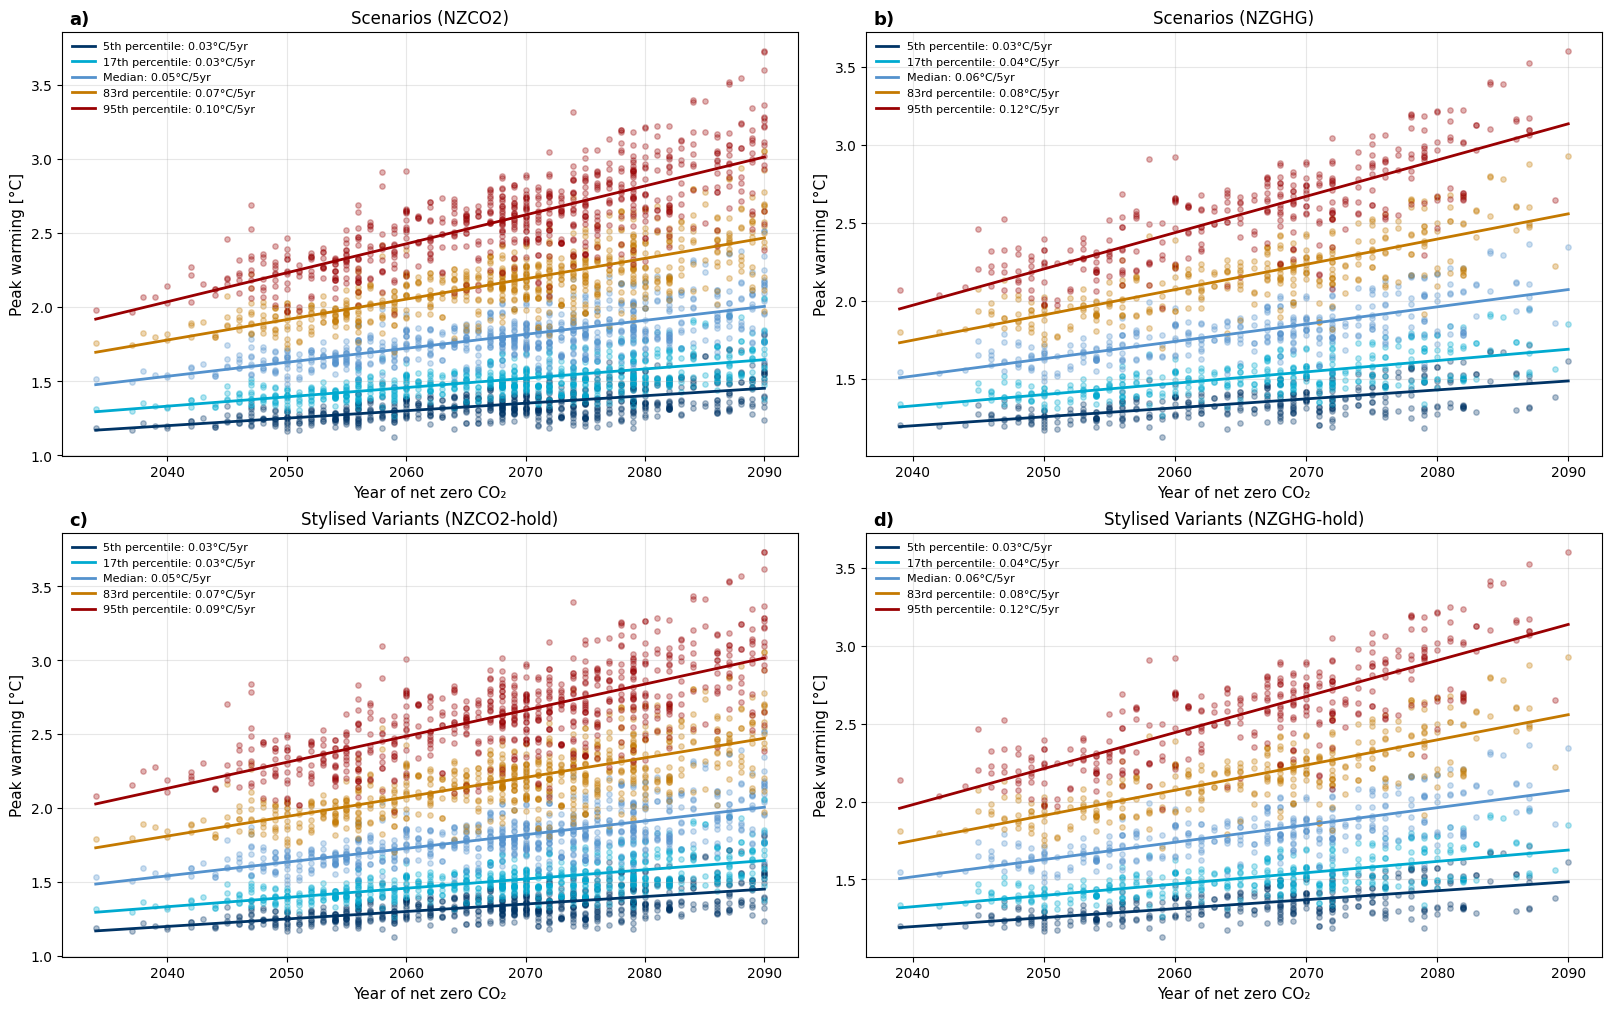

In [109]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

percentile_colors = {
    "peak_p05":    "#003466",
    "peak_p17":    "#00aad0",
    "peak_median": "#5492cd",
    "peak_p83":    "#c47900",
    "peak_p95":    "#990002",
}
percentile_labels = {
    "peak_p05":    "5th percentile",
    "peak_p17":    "17th percentile",
    "peak_median": "Median",
    "peak_p83":    "83rd percentile",
    "peak_p95":    "95th percentile",
}
cols_to_plot = ["peak_p05", "peak_p17", "peak_median", "peak_p83", "peak_p95"]

groups = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]

for ax, scenario_group in zip(axes.flatten(), groups):
    group_df = metrics_df_full[metrics_df_full["scenario_group"] == scenario_group]

    scenario_stats = group_df.groupby(["model", "scenario"]).agg({
        "GSAT|ANTHROPOGENIC|peak": [
            lambda x: x.quantile(0.05),
            lambda x: x.quantile(0.17),
            "median",
            lambda x: x.quantile(0.83),
            lambda x: x.quantile(0.95),
        ],
        "year_netzero_co2": "first",
    }).reset_index()
    scenario_stats.columns = [
        "model", "scenario",
        "peak_p05", "peak_p17", "peak_median", "peak_p83", "peak_p95",
        "year_netzero_co2",
    ]

    plot_data = scenario_stats.dropna(subset=["year_netzero_co2"]).copy()
    x_all = plot_data["year_netzero_co2"].values
    x_fit = np.linspace(x_all.min(), x_all.max(), 100)

    for col in cols_to_plot:
        y = plot_data[col].values
        hex_color = percentile_colors[col]
        label = percentile_labels[col]

        ax.scatter(x_all, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.3, s=15)

        valid = ~np.isnan(y)
        if valid.sum() > 1:
            slope, intercept = np.polyfit(x_all[valid], y[valid], 1)
            ax.plot(x_fit, slope * x_fit + intercept,
                    color=hex_color, linewidth=2,
                    label=f"{label}: {slope*5:.2f}°C/5yr")

    ax.set_xlabel("Year of net zero CO₂", fontsize=11)
    ax.set_ylabel("Peak warming [°C]", fontsize=11)
    ax.set_title(scenario_group, fontsize=12)
    ax.legend(fontsize=8, loc="upper left", frameon=False)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="both", labelsize=10)

# Panel labels
for ax, label in zip(axes.flatten(), ["a)", "b)", "c)", "d)"]):
    ax.annotate(label, xy=(0.01, 1.05), xycoords="axes fraction",
                fontsize=13, fontweight="bold", va="top", ha="left")

plt.savefig(PLOT_FOLDER / "GSAT_peak_percentiles_vs_nzco2_4panel.png", dpi=300, bbox_inches="tight")
plt.show()

In [242]:
# Calculate median and percentiles of GSAT|ANTHROPOGENIC|peak per scenario
scenario_stats = metrics_df.groupby(["model", "scenario", "scenario_group"]).agg({
    "GSAT|ANTHROPOGENIC|peak": [
        lambda x: x.quantile(0.05),
        lambda x: x.quantile(0.17),
        "median",
        lambda x: x.quantile(0.83),
        lambda x: x.quantile(0.95)
    ],
 #   "GSAT|ANTHROPOGENIC|delta_netzero_co2": "median",
 #   "GSAT|CO2_NZCO2|delta_netzero_co2": "median",
    "year_netzero_co2": "first",
    "cumulative_netnegative_co2": "first",
    "ch4_decline": "first",
    "ch4_decline_group": "first"
}).reset_index()

# Flatten column names
scenario_stats.columns = ["model", "scenario", "scenario_group", "peak_p05", "peak_p17", "peak_median", "peak_p83", "peak_p95",
                       #   "delta_all_median", "delta_co2_nzco2_median", 
                          "year_netzero_co2", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"]

print(f"Scenarios: {len(scenario_stats)}")
print(f"\nCH4 decline group value counts:")
print(scenario_stats["ch4_decline_group"].value_counts(dropna=False))
print(f"\nUnique values: {scenario_stats['ch4_decline_group'].unique()}")

Scenarios: 2026

CH4 decline group value counts:
ch4_decline_group
High CH4 decline      722
Medium CH4 decline    676
Low CH4 decline       628
Name: count, dtype: int64

Unique values: ['High CH4 decline' 'Low CH4 decline' 'Medium CH4 decline']


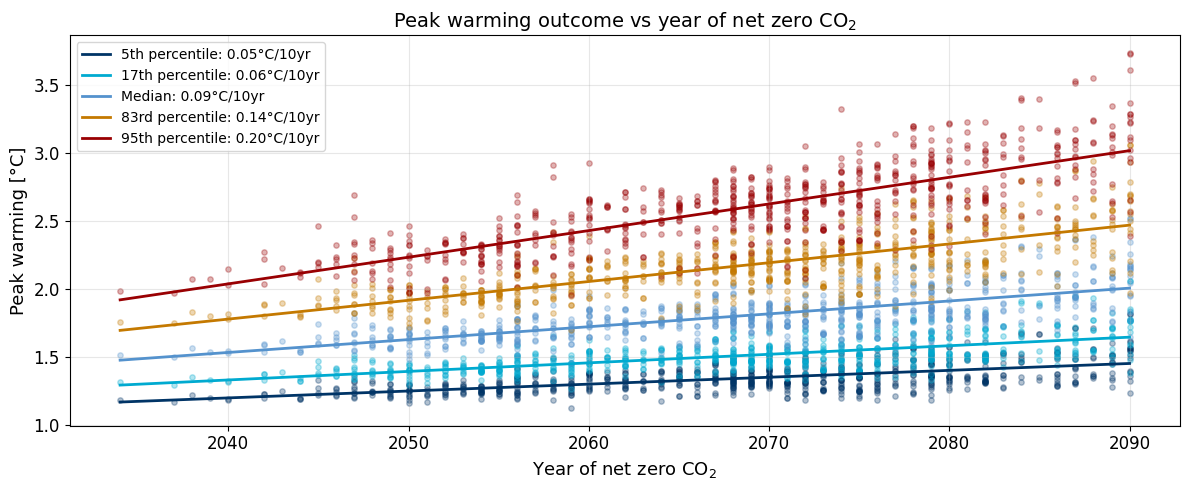

In [244]:
# Calculate median and percentiles of GSAT|ANTHROPOGENIC|peak per scenario
scenario_stats = metrics_df.groupby(["model", "scenario", "scenario_group"]).agg({
    "GSAT|ANTHROPOGENIC|peak": [
        lambda x: x.quantile(0.05),
        lambda x: x.quantile(0.17),
        "median",
        lambda x: x.quantile(0.83),
        lambda x: x.quantile(0.95)
    ],
 #   "GSAT|ANTHROPOGENIC|delta_netzero_co2": "median",
 #   "GSAT|CO2_NZCO2|delta_netzero_co2": "median",
    "year_netzero_co2": "first",
    "cumulative_netnegative_co2": "first",
    "ch4_decline": "first",
    "ch4_decline_group": "first"
}).reset_index()

# Flatten column names
scenario_stats.columns = ["model", "scenario", "scenario_group", "peak_p05", "peak_p17", "peak_median", "peak_p83", "peak_p95",
                       #   "delta_all_median", "delta_co2_nzco2_median", 
                          "year_netzero_co2", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"]

print(f"Scenarios: {len(scenario_stats)}")
print(f"\nCH4 decline group value counts:")
print(scenario_stats["ch4_decline_group"].value_counts(dropna=False))
print(f"\nUnique values: {scenario_stats['ch4_decline_group'].unique()}")


fig, ax = plt.subplots(figsize=(12, 5))

# Filter for valid data
plot_data = scenario_stats.dropna(subset=["year_netzero_co2"]).copy()
plot_data = plot_data[plot_data["scenario_group"]=="Scenarios (NZCO2)"]

x_all = plot_data["year_netzero_co2"].values
x_fit = np.linspace(plot_data["year_netzero_co2"].min(), plot_data["year_netzero_co2"].max(), 100)

percentile_colors = {
    "peak_p05":     "#003466",
    "peak_p17":     "#00aad0",
    "peak_median":  "#5492cd",
    "peak_p83":     "#c47900",
    "peak_p95":     "#990002",
}
percentile_labels = {
    "peak_p05":     "5th percentile",
    "peak_p17":     "17th percentile",
    "peak_median":  "Median",
    "peak_p83":     "83rd percentile",
    "peak_p95":     "95th percentile",
}

for col in ["peak_p05", "peak_p17", "peak_median", "peak_p83", "peak_p95"]:
    y = plot_data[col].values
    hex_color = percentile_colors[col]
    label = percentile_labels[col]

    ax.scatter(x_all, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.3, s=15)

    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x_all[valid], y[valid], 1)
        ax.plot(x_fit, slope * x_fit + intercept,
                color=hex_color, linewidth=2,
                label=f"{label}: {slope*10:.2f}°C/10yr")

ax.set_xlabel("Year of net zero CO$_2$", fontsize=13)
#ax.set_ylabel("GSAT in year of net zero CO$_2$ [°C]", fontsize=13)
ax.set_ylabel("Peak warming [°C]", fontsize=13)
ax.set_title("Peak warming outcome vs year of net zero CO$_2$", fontsize=14)
ax.legend(fontsize=10, loc="upper left")
ax.grid(alpha=0.3)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "GSAT_peak_vs_nzco2-10.png", dpi=300, bbox_inches="tight")
plt.show()

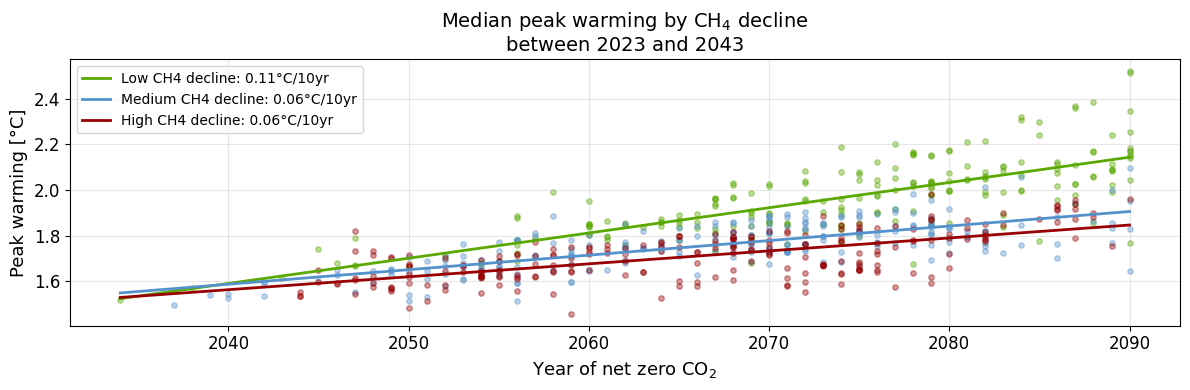

In [252]:
fig, ax = plt.subplots(figsize=(12, 4))

# Filter for valid data
plot_data = scenario_stats.dropna(subset=["year_netzero_co2"]).copy()
plot_data = plot_data[plot_data["scenario_group"]=="Scenarios (NZCO2)"]

GROUP_COLORS = {
    "Low CH4 decline": "#59a900",      # Bright Green
    "Medium CH4 decline": "#5492cd",   # IPCC Blue
    "High CH4 decline": "#990002",     # Warm Red
}

for group in ["Low CH4 decline", "Medium CH4 decline", "High CH4 decline"]:
    subset = plot_data[plot_data["ch4_decline_group"] == group]
    x = subset["year_netzero_co2"].values
    y = subset["peak_median"].values
    hex_color = GROUP_COLORS[group]
    
    ax.scatter(x, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.4, s=15)
    
    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x[valid], y[valid], 1)
        ax.plot(x_fit, slope * x_fit + intercept, 
                color=hex_color, linewidth=2,
                label=f"{group}: {slope*10:.2f}°C/10yr")

ax.set_xlabel("Year of net zero CO$_2$", fontsize=13)
ax.set_ylabel("Peak warming [°C]", fontsize=13)
ax.set_title("Median peak warming by CH$_4$ decline\nbetween 2023 and 2043", fontsize=14)
ax.legend(fontsize=10, loc="upper left")
ax.grid(alpha=0.3)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()

plt.savefig(PLOT_FOLDER / "GSAT_peak_vs_nzco2_CH4-10.png", dpi=300, bbox_inches="tight")
plt.show()

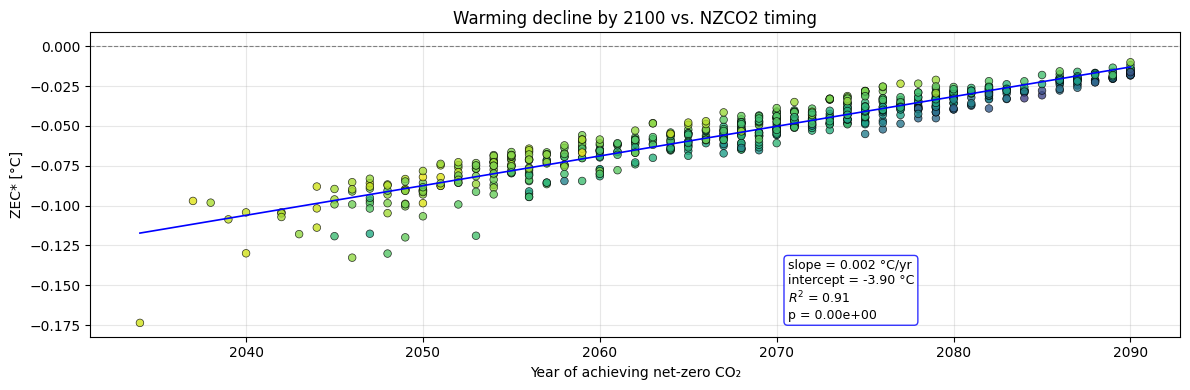

In [253]:
# ------------------------------------------------------------------
# Data
# ------------------------------------------------------------------
plot_data = (
    metrics_df[metrics_df["scenario_group"]=="Stylised Variants (NZCO2-hold)"]
    .groupby(["model", "scenario"])[
        ["GSAT|CO2_NZCO2|delta_netzero_co2", "GSAT|ANTHROPOGENIC|peak", "year_netzero_co2"]
    ]
    .median()
    .reset_index()
    .dropna(subset=["GSAT|CO2_NZCO2|delta_netzero_co2", "year_netzero_co2"])
)

# ------------------------------------------------------------------
# Linear regression for panel a)
# ------------------------------------------------------------------
x = plot_data["year_netzero_co2"].values
y = plot_data["GSAT|CO2_NZCO2|delta_netzero_co2"].values
slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept

# ------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

# ------------------------------------------------------------------
# Panel a)
# ------------------------------------------------------------------
sc1 = ax.scatter(
    plot_data["year_netzero_co2"],
    plot_data["GSAT|CO2_NZCO2|delta_netzero_co2"],
    c=plot_data["GSAT|ANTHROPOGENIC|peak"],
    cmap="viridis_r",
    alpha=0.8,
    s=30,
    edgecolors="black",
    linewidths=0.5,
    zorder=2
)
ax.plot(x_fit, y_fit, color="blue", linewidth=1.2, label="Linear fit", zorder=3)
ax.text(
    0.64, 0.05,
    f"slope = {slope:.3f} °C/yr\nintercept = {intercept:.2f} °C\n$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=ax.transAxes,
    fontsize=9,
    va="bottom",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="blue", alpha=0.8)
)
cbar1 = fig.colorbar(sc1, ax=ax1)
cbar1.set_label("Peak Warming [°C]")
ax.set_xlabel("Year of achieving net-zero CO₂")
ax.set_ylabel("ZEC* [°C]")
ax.set_title("Warming decline by 2100 vs. NZCO2 timing")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.grid(alpha=0.3, zorder=0)

plt.tight_layout()

plt.savefig(PLOT_FOLDER / "ZEC_vs_nzco2.png", dpi=300, bbox_inches="tight")
plt.show()

In [270]:
def add_density(ax, data, color, ax_right=None):
    data = data.dropna()
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    if ax_right is None:
        ax_right = ax.twinx()
    ax_right.plot(x_range, kde(x_range), color=color, linewidth=1.5)
    ax_right.set_ylabel("Density")
    ax_right.set_ylim(bottom=0)
    return ax_right

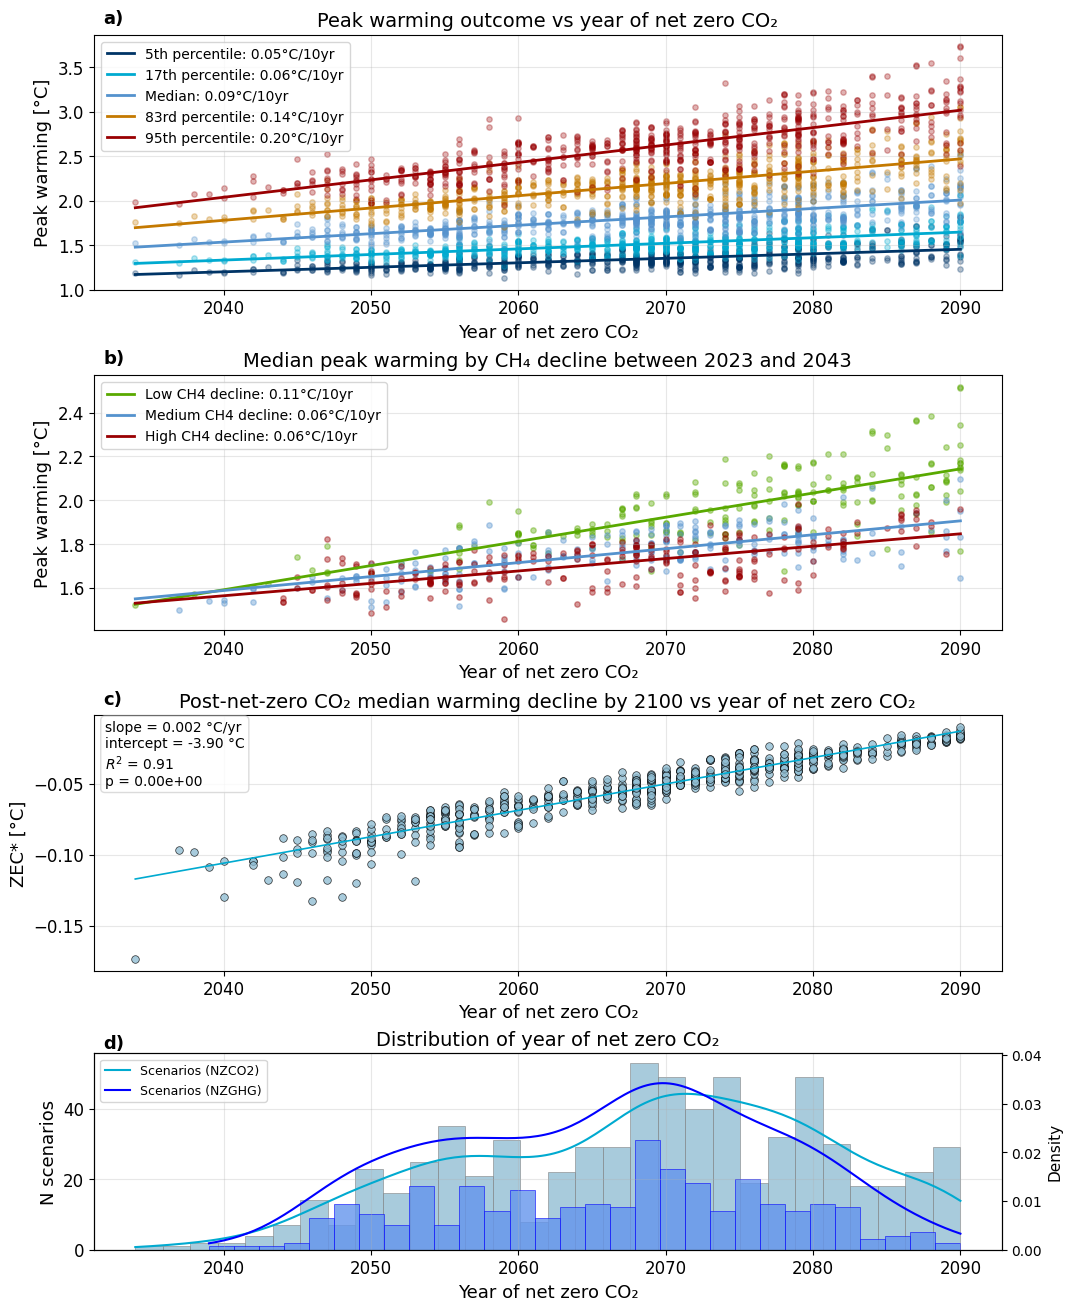

In [365]:
# ------------------------------------------------------------------
# Data prep (shared)
# ------------------------------------------------------------------
scenario_stats = metrics_df.groupby(["model", "scenario", "scenario_group"]).agg({
    "GSAT|ANTHROPOGENIC|peak": [
        lambda x: x.quantile(0.05),
        lambda x: x.quantile(0.17),
        "median",
        lambda x: x.quantile(0.83),
        lambda x: x.quantile(0.95)
    ],
    "year_netzero_co2": "first",
    "cumulative_netnegative_co2": "first",
    "ch4_decline": "first",
    "ch4_decline_group": "first"
}).reset_index()
scenario_stats.columns = [
    "model", "scenario", "scenario_group",
    "peak_p05", "peak_p17", "peak_median", "peak_p83", "peak_p95",
    "year_netzero_co2", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"
]

# Panel a/b data
plot_data_ab = (
    scenario_stats
    .dropna(subset=["year_netzero_co2"])
    .pipe(lambda df: df[df["scenario_group"] == "Scenarios (NZCO2)"])
    .copy()
)
x_all_ab = plot_data_ab["year_netzero_co2"].values
x_fit_ab = np.linspace(x_all_ab.min(), x_all_ab.max(), 100)

# Panel c data
plot_data_c = (
    metrics_df[metrics_df["scenario_group"] == "Stylised Variants (NZCO2-hold)"]
    .groupby(["model", "scenario"])[
        ["GSAT|CO2_NZCO2|delta_netzero_co2", "GSAT|ANTHROPOGENIC|peak", "year_netzero_co2"]
    ]
    .median()
    .reset_index()
    .dropna(subset=["GSAT|CO2_NZCO2|delta_netzero_co2", "year_netzero_co2"])
)
x_c = plot_data_c["year_netzero_co2"].values
y_c = plot_data_c["GSAT|CO2_NZCO2|delta_netzero_co2"].values
slope_c, intercept_c, r_value_c, p_value_c, _ = scipy_stats.linregress(x_c, y_c)
x_fit_c = np.linspace(x_c.min(), x_c.max(), 100)
y_fit_c = slope_c * x_fit_c + intercept_c

# Panel d data
plot_data_d_nzco2 = (
    scenario_stats
    .dropna(subset=["year_netzero_co2"])
    .pipe(lambda df: df[df["scenario_group"] == "Scenarios (NZCO2)"])
    .copy()
)
plot_data_d_nzghg = (
    scenario_stats
    .dropna(subset=["year_netzero_co2"])
    .pipe(lambda df: df[df["scenario_group"] == "Scenarios (NZGHG)"])
    .copy()
)

# ------------------------------------------------------------------
# Color/label dicts
# ------------------------------------------------------------------
percentile_colors = {
    "peak_p05":    "#003466",
    "peak_p17":    "#00aad0",
    "peak_median": "#5492cd",
    "peak_p83":    "#c47900",
    "peak_p95":    "#990002",
}
percentile_labels = {
    "peak_p05":    "5th percentile",
    "peak_p17":    "17th percentile",
    "peak_median": "Median",
    "peak_p83":    "83rd percentile",
    "peak_p95":    "95th percentile",
}
GROUP_COLORS = {
    "Low CH4 decline":    "#59a900",
    "Medium CH4 decline": "#5492cd",
    "High CH4 decline":   "#990002",
}

# ------------------------------------------------------------------
# Figure layout — 4 panels with unequal heights
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    4, 1,
    figsize=(10, 13),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1.3, 1.3, 1.3, 1]}
)
ax_a, ax_b, ax_c, ax_d = axes

# ------------------------------------------------------------------
# Panel a) — percentile scatter
# ------------------------------------------------------------------
for col in ["peak_p05", "peak_p17", "peak_median", "peak_p83", "peak_p95"]:
    y = plot_data_ab[col].values
    hex_color = percentile_colors[col]
    label = percentile_labels[col]
    ax_a.scatter(x_all_ab, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.3, s=15)
    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x_all_ab[valid], y[valid], 1)
        ax_a.plot(x_fit_ab, slope * x_fit_ab + intercept,
                  color=hex_color, linewidth=2,
                  label=f"{label}: {slope*10:.2f}°C/10yr")
ax_a.set_xlabel("Year of net zero CO₂", fontsize=13)
ax_a.set_ylabel("Peak warming [°C]", fontsize=13)
ax_a.set_title("Peak warming outcome vs year of net zero CO₂", fontsize=14)
ax_a.legend(fontsize=10, loc="upper left")
ax_a.grid(alpha=0.3)
ax_a.tick_params(axis="both", labelsize=12)

# ------------------------------------------------------------------
# Panel b) — CH4 decline groups
# ------------------------------------------------------------------
for group in ["Low CH4 decline", "Medium CH4 decline", "High CH4 decline"]:
    subset = plot_data_ab[plot_data_ab["ch4_decline_group"] == group]
    x = subset["year_netzero_co2"].values
    y = subset["peak_median"].values
    hex_color = GROUP_COLORS[group]
    ax_b.scatter(x, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.4, s=15)
    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x[valid], y[valid], 1)
        ax_b.plot(x_fit_ab, slope * x_fit_ab + intercept,
                  color=hex_color, linewidth=2,
                  label=f"{group}: {slope*10:.2f}°C/10yr")
ax_b.set_xlabel("Year of net zero CO₂", fontsize=13)
ax_b.set_ylabel("Peak warming [°C]", fontsize=13)
ax_b.set_title("Median peak warming by CH₄ decline between 2023 and 2043", fontsize=14)
ax_b.legend(fontsize=10, loc="upper left")
ax_b.grid(alpha=0.3)
ax_b.tick_params(axis="both", labelsize=12)

# ------------------------------------------------------------------
# Panel c) — ZEC* scatter with regression
# ------------------------------------------------------------------
sc_c = ax_c.scatter(
    plot_data_c["year_netzero_co2"],
    plot_data_c["GSAT|CO2_NZCO2|delta_netzero_co2"],
    c="#92BFD4",
    alpha=0.8,
    s=30,
    edgecolors="black",
    linewidths=0.5,
    zorder=2
)
ax_c.plot(x_fit_c, y_fit_c, color="#00aad0", linewidth=1.2, label="Linear fit", zorder=3)
ax_c.text(
    0.012, 0.714,
    f"slope = {slope_c:.3f} °C/yr\nintercept = {intercept_c:.2f} °C\n$R^2$ = {r_value_c**2:.2f}\np = {p_value_c:.2e}",
    transform=ax_c.transAxes,
    fontsize=10,
    va="bottom",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgrey", alpha=0.8)
)
ax_c.set_xlabel("Year of net zero CO₂", fontsize=13)
ax_c.set_ylabel("ZEC* [°C]", fontsize=13)
ax_c.set_title("Post-net-zero CO₂ median warming decline by 2100 vs year of net zero CO₂", fontsize=14)
ax_c.grid(alpha=0.3, zorder=0)
ax_c.tick_params(axis="both", labelsize=12)

# ------------------------------------------------------------------
# Panel d) — histogram of NZCO2 timing
# ------------------------------------------------------------------
ax_d.hist(
    plot_data_d_nzco2["year_netzero_co2"],
    bins=30, color="#92BFD4", edgecolor="grey", linewidth=0.5, alpha=0.8
)
ax_right_d = add_density(ax_d, plot_data_d_nzco2["year_netzero_co2"].dropna(), color="#00aad0")
ax_right_d.set_position(ax_d.get_position())  # force alignment

ax_d.hist(
    plot_data_d_nzghg["year_netzero_co2"],
    bins=30, color="cornflowerblue", edgecolor="blue", linewidth=0.5, alpha=0.8
)
add_density(ax_d, plot_data_d_nzghg["year_netzero_co2"].dropna(), color="blue", ax_right=ax_right_d)

ax_d.set_xlabel("Year of net zero CO₂", fontsize=13)
ax_d.set_ylabel("N scenarios", fontsize=13)
ax_d.set_title("Distribution of year of net zero CO₂", fontsize=14)
ax_d.grid(alpha=0.3, zorder=0)
ax_d.tick_params(axis="both", labelsize=12)

current_ymax = ax_right_d.get_ylim()[1]
ax_right_d.set_ylim(0, current_ymax * 1.2)
ax_right_d.set_ylabel("Density", fontsize=11)

legend_handles = [
    Line2D([0], [0], color="#00aad0", linewidth=1.5, label="Scenarios (NZCO2)"),
    Line2D([0], [0], color="blue", linewidth=1.5, label="Scenarios (NZGHG)"),
]
ax_right_d.legend(handles=legend_handles, fontsize=9, loc="upper left",
                  frameon=True, framealpha=0.8)

# ------------------------------------------------------------------
# Panel labels
# ------------------------------------------------------------------
for ax, label in zip([ax_a, ax_b, ax_c, ax_d], ["a)", "b)", "c)", "d)"]):
    ax.annotate(label, xy=(0.01, 1.1), xycoords="axes fraction",
                fontsize=13, fontweight="bold", va="top", ha="left")

plt.savefig(PLOT_FOLDER / "504_NZCO2_timing.png", dpi=300, bbox_inches="tight")
plt.show()